# Quadrature Phase Shift Keying



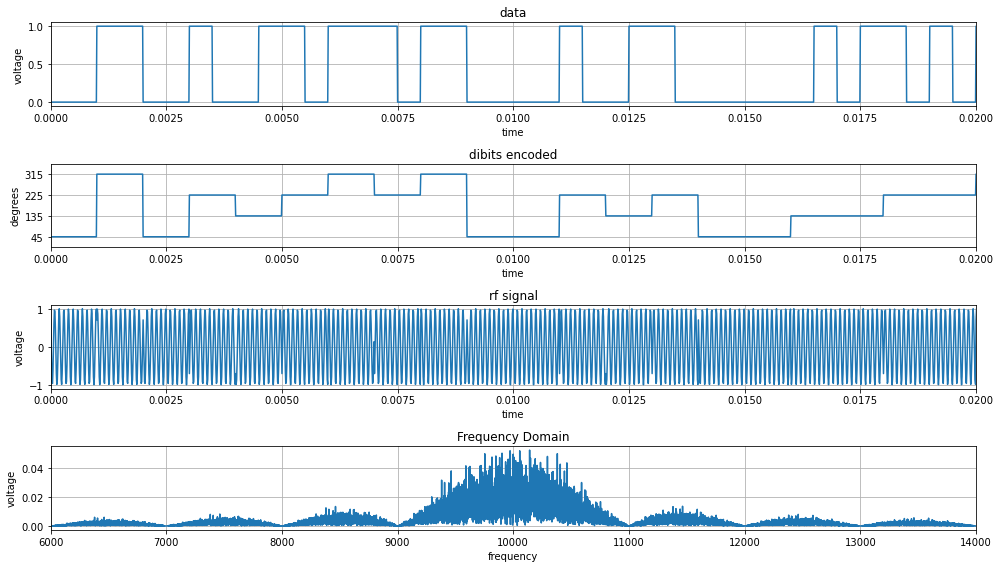

In [17]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# Generate time vector
fs = 96000  # sample rate
Ts = 1/fs  # time step
Tmax = 2 # total simulation time
t = np.arange(0, Tmax, Ts)  # time vector start / end / step

# baseband square wave
bitrate = 2000  # /s

#random data stream
data = np.random.randint(0, 2, bitrate * Tmax) 
dibits = data.reshape(-1, 2) # 2 bits together

# Map dibits to values (00=0, 01=1, 10=2, 11=3) and multiply by angle in rad
angles = (dibits[:, 0] * 2 + dibits[:, 1]) * np.pi/2 + np.pi/4 # 45°, 135°, 225°, 315°
angles_expanded = np.repeat(angles, fs/(bitrate/2)) # half symbol rate because of dibits

# carrier
Uc = 1 # V
fc = 10000 # Hz
u_qpsk = Uc * np.cos(2 * np.pi * fc * t + angles_expanded)


# Calculate Frequency Spectrum
# with Fast Fourier Transformation (FFT)
n = len(u_qpsk)  # number of samples
F = np.fft.fft(u_qpsk)[:n//2]  # complex fourier coefficient (= amplitude) at each pos. frequency
f = np.fft.fftfreq(n, Ts)[:n//2] # n Elemente mit Abstand Ts (pos. Frequenzen)
volt = 2/n * np.abs(F)  # absolute value of amplitude

# calculate peaks in spectrum
# peakfreq, _ = signal.find_peaks(volt, height=1e-3)
# print(peakfreq * fs/n) # scale frequencies
# print(volt[peakfreq]) # amplitudes

# Plot Time Domain (Zeitbereichsdarstellung)
plt.figure(figsize=(14, 8))

plt.subplot(4, 1, 1)  
plt.plot(t, np.repeat(data, fs/bitrate))
plt.grid(True)
plt.xlim(0, 0.02)
plt.title('data') 
plt.xlabel('time')
plt.ylabel('voltage')

plt.subplot(4, 1, 2) 
plt.plot(t, angles_expanded*180/np.pi)
plt.grid(True)
plt.xlim(0, 0.02)
plt.ylim(0, 360)
plt.yticks([45, 135, 225, 315])
plt.title('dibits encoded') 
plt.xlabel('time')
plt.ylabel('degrees')

plt.subplot(4, 1, 3) 
plt.plot(t, u_qpsk)
plt.grid(True)
plt.xlim(0, 0.02)
plt.title('rf signal') 
plt.xlabel('time')
plt.ylabel('voltage')

# Plot Frequency Domain (Frequenzbereichsdarstellung)
plt.subplot(4, 1, 4)  
plt.plot(f, volt)
plt.grid(True)
#plt.axis([5000, 15000, 0, 2.5])
plt.xlim(6000, 14000)
plt.title('Frequency Domain')  
plt.xlabel('frequency')
plt.ylabel('voltage')

plt.tight_layout()
plt.show()



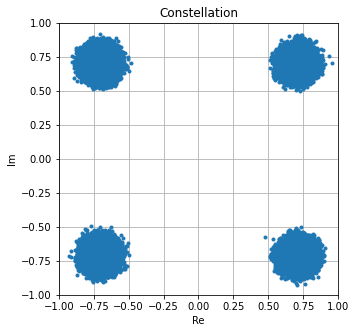

In [18]:
# Constellation with noise added
noise = (np.random.randn(len(angles_expanded)) + 1j*np.random.randn(len(angles_expanded)))
noiselevel = 0.05
symbols = np.cos(angles_expanded) + 1j*np.sin(angles_expanded) + noise * noiselevel

plt.figure(figsize=(5, 5))
plt.title('Constellation') 
plt.xlabel('Re')
plt.ylabel('Im')
plt.axis([-1, 1, -1, 1])
plt.grid(True)
plt.plot(np.real(symbols), np.imag(symbols), '.')
plt.show()
